# The Mandelbrot set

The Mandelbrot set is defined as the set of complex numbers $c$ for which the iterative sequence: 
$z_{n+1} = z_n^2 + c$

with $z_0 = 0$, remains bounded (doesn't diverge to infinity) which we define as, $|z_{n+1}| \leq 2$ for all $n$.

So the first interations of the sequence looks like this.
$z_0 = 0$   
$z_1 = 0 + c = c$   
$z_2 = c² + c$  
$z_3 = (c²+c)² + c$     
...

## The naive approach in Python.
When calculating all the values in the Mandelbrot set, one could take a naive approach. Disregarding any optimization choices and use default python lists and nested for loops:

In [5]:
# Define the limits and parameters for the mandelbrot set.
# The typical view (limits) as defined by the problem description from moodle.
x_min = -2.0 
x_max =  1.0
y_min = -1.5
y_max =  1.5

# Minimum resolution to start with.
width = 1024
height = 1024

# Larger max_iterations than suggested in moodle (1000 instead of 100) to help emphisize the difference between solution.
max_iterations = 1000


def mandelbrot(c, max_iterations):
    z = 0
    n = 0

    # Keep interating as long as the magnitude of z is less than or equal to 2 (doesn't diverge to infinity) and we haven't reached the maximum number of iterations.
    while abs(z) <= 2.0 and n < max_iterations:
        z = z*z + c
        n += 1
    return n


def generate_mandelbrot_set_naive():

    # Create a naive 2D list to hold the values.
    mandelbrot_set = [[0 for _ in range(width)] for _ in range(height)]

    # Loop through all pixels and determine how many iterations it takes for the corresponding magnitude to become greater than 2 (indicating divergence to infinity).
    for y in range(height):
        for x in range(width):
            real = x_min + (x / width) * (x_max - x_min)
            imag = y_min + (y / height) * (y_max - y_min)
            c = complex(real, imag)
            mandelbrot_set[y][x] = mandelbrot(c, max_iterations)

    return mandelbrot_set

mandelbrot_set_naive = generate_mandelbrot_set_naive()
%timeit generate_mandelbrot_set_naive()


11.5 s ± 28.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


As we can see the naive approach results in each function call taking seconds to complete at this scale (1024 x 1024).

Using a colorbar plot we can visualize the set and confirm that we yield the expected result:

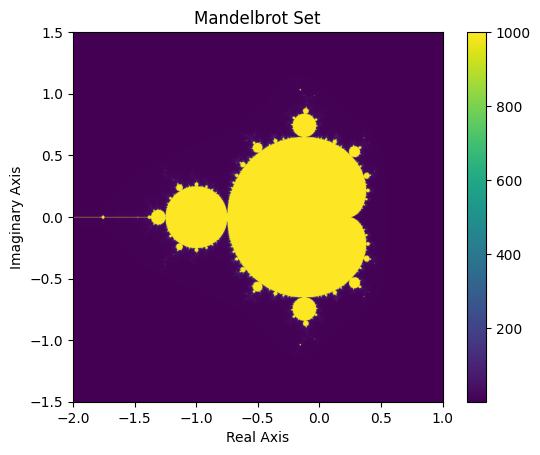

In [6]:
import matplotlib.pyplot as plt

# Plotting the set using colorbar.
plt.imshow(mandelbrot_set_naive, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()